In [1]:
#@title # PETase 1D Dataset Curation
# =============================================================================
# This notebook cleans & curates the training set from 4 sources (PlasticDB, PAZy, PlasticEnz, PED)

In [3]:
#@title # Mount Google Drive & Install dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install -q biopython transformers scikit-learn umap-learn matplotlib seaborn pandas numpy tqdm
# CD-HIT is used for sequence identity-based screening (optional, more
# authoritative than cosine embedding similarity). Installation via conda/apt:
!apt-get -qq install -y cd-hit > /dev/null 2>&1 || echo "cd-hit failed to install via apt -- screening will use embedding similarity only"

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.9 MB/s eta 0:00:00


In [4]:
#@title # Import Library
import os
import pandas as pd
import numpy as np
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import re
import subprocess
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [5]:
#@title # 1. Configure data source paths
import os

PROJECT_ROOT = "/content/drive/MyDrive/InterPET"
DATASETS_DIR = os.path.join(PROJECT_ROOT, "datasets")
os.makedirs(DATASETS_DIR, exist_ok=True)

TEMP_DIR = os.path.join(PROJECT_ROOT, "temp_curation")
os.makedirs(TEMP_DIR, exist_ok=True)

# -----------------------------------------------------------------------------
# ADJUST the following paths to your file locations in Drive.
# Supported formats: FASTA (.fasta/.fa) for sequences, TSV/CSV for labels.
# Set to None if a source is not used / file not available yet.
# -----------------------------------------------------------------------------

# --- Input file paths ---
INPUT_DATA_DIR = os.path.join(PROJECT_ROOT, "input")

# 1. PlasticDB
PLASTICDB_FASTA = os.path.join(INPUT_DATA_DIR, "PlasticDB.fasta")

# 2. PAZy
PAZY_CSV = os.path.join(INPUT_DATA_DIR, "pazy.csv")

# 3. PlasticEnz
PLASTICENZ_TRAIN_FASTA = os.path.join(INPUT_DATA_DIR, "train.fasta")
PLASTICENZ_TRAIN_LABELS = os.path.join(INPUT_DATA_DIR, "train_labels.tsv")

# 4. PED
PED_EXCEL = os.path.join(INPUT_DATA_DIR, "PED.xlsx")

# 5. Benchmark (PlasticEnz test)
BENCHMARK_FASTA = os.path.join(INPUT_DATA_DIR, "test.fasta")
BENCHMARK_LABELS = os.path.join(INPUT_DATA_DIR, "test_labels.tsv")

print("=" * 60)
print("PETase Dataset Curation")
print("=" * 60)
print(f"PlasticDB  : {os.path.exists(PLASTICDB_FASTA)}")
print(f"PAZy       : {os.path.exists(PAZY_CSV)}")
print(f"PlasticEnz : {os.path.exists(PLASTICENZ_TRAIN_FASTA)}")
print(f"PED        : {os.path.exists(PED_EXCEL)}")
print(f"Benchmark  : {os.path.exists(BENCHMARK_FASTA)}")
print("=" * 60)

PETase Dataset Curation
PlasticDB  : True
PAZy       : True
PlasticEnz : True
PED        : True
Benchmark  : True


In [6]:
#@title # 2. Loader Functions
def load_plasticdb(fasta_path):
    """
    Load PlasticDB FASTA.
    Header format: >ID|enzyme|organism|substrates|accession
    Positive: if "PET" is in substrates
    Negative: if "PET" is NOT in substrates
    """
    if not os.path.exists(fasta_path):
        print(f"  [SKIP] PlasticDB: file not found")
        return [], []

    positive = []
    negative = []

    for rec in SeqIO.parse(fasta_path, "fasta"):
        seq = str(rec.seq).upper().replace("*", "")
        if len(seq) < 20:
            continue

        # Parse header: ID|enzyme|organism|substrates|accession
        parts = rec.id.split("|")
        if len(parts) >= 4:
            enzyme = parts[1] if len(parts) > 1 else ""
            organism = parts[2] if len(parts) > 2 else ""
            substrates = parts[3] if len(parts) > 3 else ""
            accession = parts[4] if len(parts) > 4 else ""
        else:
            enzyme = rec.id
            organism = ""
            substrates = ""
            accession = ""

        # Check if PET is in substrates
        is_pet = "PET" in substrates.upper()

        record = {
            "id": rec.id,
            "sequence": seq,
            "source": "PlasticDB",
            "enzyme": enzyme,
            "organism": organism,
            "substrates": substrates,
            "accession": accession
        }

        if is_pet:
            positive.append(record)
        else:
            negative.append(record)

    print(f"  [OK] PlasticDB: {len(positive)} positive (PET), {len(negative)} negative (non-PET)")
    return positive, negative


def load_pazy(csv_path):
    """
    Load PAZy CSV with semicolon (;) delimiter.
    Format: protein_id;protein_name;amino_acid_sequences;...;substrates;...
    Positive: if "PET" is in substrates
    Negative: if "PET" is NOT in substrates
    """
    if not os.path.exists(csv_path):
        print(f"  [SKIP] PAZy: file not found: {csv_path}")
        return [], []

    # Use semicolon (;) delimiter
    df = pd.read_csv(csv_path, sep=';')

    print(f"  PAZy columns: {list(df.columns)[:15]}...")  # Display first 15 columns

    # Find sequence column
    seq_col = None
    for col in df.columns:
        if col in ['amino_acid_sequences', 'sequence', 'seq', 'protein_sequence']:
            seq_col = col
            break

    if seq_col is None:
        print(f"  ERROR: Sequence column not found!")
        print(f"  Columns: {list(df.columns)}")
        return [], []

    print(f"  Using column '{seq_col}' as sequence")

    # Find substrates column
    sub_col = None
    for col in df.columns:
        if col in ['substrates', 'substrate', 'Substrate']:
            sub_col = col
            break

    if sub_col is None:
        print(f"  WARNING: Substrates column not found, trying 'protein_name'")
        sub_col = 'protein_name'

    print(f"  Using column '{sub_col}' for substrates")

    # Find protein_id column
    id_col = None
    for col in df.columns:
        if col in ['protein_id', 'id', 'ID']:
            id_col = col
            break

    if id_col is None:
        id_col = df.columns[0]

    positive = []
    negative = []

    for idx, row in df.iterrows():
        seq = str(row[seq_col]).upper().replace("*", "").replace(" ", "")

        # Skip if sequence is empty or too short
        if len(seq) < 20 or seq == "NAN" or seq == "":
            continue

        # Get substrates (if available)
        substrates = str(row[sub_col]) if pd.notna(row[sub_col]) else ""
        protein_id = str(row[id_col]) if pd.notna(row[id_col]) else str(idx)

        # Check if PET is in substrates
        is_pet = "PET" in substrates.upper()

        record = {
            "id": f"PAZY_{protein_id}",
            "sequence": seq,
            "source": "PAZy",
            "substrates": substrates,
            "protein_id": protein_id
        }

        if is_pet:
            positive.append(record)
        else:
            negative.append(record)

    print(f"  [OK] PAZy: {len(positive)} positive (PET), {len(negative)} negative (non-PET)")
    return positive, negative

def load_plasticenz(fasta_path, labels_path):
    """
    Load PlasticEnz train data.
    Positive: PET=1 in labels
    Negative: PET=0 in labels
    """
    if not os.path.exists(fasta_path) or not os.path.exists(labels_path):
        print(f"  [SKIP] PlasticEnz: file not found")
        return [], []

    labels_df = pd.read_csv(labels_path, sep="\t")
    print(f"  PlasticEnz labels columns: {list(labels_df.columns)}")

    # Find ID column
    id_col = None
    for col in ['Numeric_ID', 'ID', 'id']:
        if col in labels_df.columns:
            id_col = col
            break
    if id_col is None:
        id_col = labels_df.columns[0]

    # Create mapping ID -> PET label
    pet_map = dict(zip(labels_df[id_col].astype(str), labels_df['PET']))

    sequences = list(SeqIO.parse(fasta_path, "fasta"))
    positive = []
    negative = []

    for rec in sequences:
        seq = str(rec.seq).upper().replace("*", "")
        if len(seq) < 20:
            continue

        seq_id = rec.id.split()[0]  # Get ID without description
        pet_label = pet_map.get(seq_id, 0)

        record = {
            "id": rec.id,
            "sequence": seq,
            "source": "PlasticEnz_train",
            "numeric_id": seq_id,
            "pet_label": pet_label
        }

        if pet_label == 1:
            positive.append(record)
        else:
            negative.append(record)

    print(f"  [OK] PlasticEnz: {len(positive)} positive (PET=1), {len(negative)} negative (PET=0)")
    return positive, negative


def load_ped(excel_path):
    """
    Load PED Excel.
    Positive: degradation=1 or category="PET"
    Negative: degradation=0 or category is not PET
    """
    if not os.path.exists(excel_path):
        print(f"  [SKIP] PED: file not found")
        return [], []

    df = pd.read_excel(excel_path)
    print(f"  PED columns: {list(df.columns)}")

    positive = []
    negative = []

    for _, row in df.iterrows():
        seq = str(row.get('sequence', '')).upper().replace("*", "")
        if len(seq) < 20:
            continue

        category = str(row.get('category', ''))
        degradation = row.get('degradation', 0)

        # Positive if category == "PET" AND degradation == 1
        is_pet = (category.upper() == "PET") and (degradation == 1)

        record = {
            "id": f"PED_{_}",
            "sequence": seq,
            "source": "PED",
            "category": category,
            "degradation": degradation
        }

        if is_pet:
            positive.append(record)
        else:
            negative.append(record)

    print(f"  [OK] PED: {len(positive)} positive (PET), {len(negative)} negative (non-PET)")
    return positive, negative


def load_benchmark(fasta_path, labels_path):
    """Load benchmark set (PlasticEnz test)"""
    if not os.path.exists(fasta_path):
        print(f"  [SKIP] Benchmark: file not found")
        return []

    if os.path.exists(labels_path):
        labels_df = pd.read_csv(labels_path, sep="\t")
        id_col = 'Numeric_ID' if 'Numeric_ID' in labels_df.columns else labels_df.columns[0]
        pet_map = dict(zip(labels_df[id_col].astype(str), labels_df['PET']))
    else:
        pet_map = {}

    records = []
    for rec in SeqIO.parse(fasta_path, "fasta"):
        seq = str(rec.seq).upper().replace("*", "")
        if len(seq) < 20:
            continue
        seq_id = rec.id.split()[0]
        label = pet_map.get(seq_id, 0)
        records.append({
            "id": rec.id,
            "sequence": seq,
            "label": label,
            "source": "benchmark"
        })

    print(f"  [OK] Benchmark: {len(records)} sequences ({sum(1 for r in records if r['label']==1)} positive)")
    return records

In [7]:
#@title # 3. Load all
print("\n" + "=" * 60)
print("LOADING ALL SOURCES")
print("=" * 60)

all_positive = []
all_negative = []

# 3.1 PlasticDB
pos, neg = load_plasticdb(PLASTICDB_FASTA)
all_positive.extend(pos)
all_negative.extend(neg)

# 3.2 PAZy
pos, neg = load_pazy(PAZY_CSV)
all_positive.extend(pos)
all_negative.extend(neg)

# 3.3 PlasticEnz
pos, neg = load_plasticenz(PLASTICENZ_TRAIN_FASTA, PLASTICENZ_TRAIN_LABELS)
all_positive.extend(pos)
all_negative.extend(neg)

# 3.4 PED
pos, neg = load_ped(PED_EXCEL)
all_positive.extend(pos)
all_negative.extend(neg)

print("\n" + "-" * 40)
print(f"Total positive (raw): {len(all_positive)}")
print(f"Total negative (raw): {len(all_negative)}")
print("-" * 40)


LOADING ALL SOURCES
  [OK] PlasticDB: 186 positive (PET), 143 negative (non-PET)
  PAZy columns: ['protein_id', 'protein_name', 'amino_acid_sequences', 'verified_activity', 'organism_id', 'organism_name', 'phylum', 'substrates', ' EMBL-GenBank-DDBJ_CDS', 'EMBL-GenBank-DDBJ_CDS', 'Ensembl_Protein', 'MGnify', 'PDB', 'RefSeq_Protein', 'UniParc']...
  Using column 'amino_acid_sequences' as sequence
  Using column 'substrates' for substrates
  [OK] PAZy: 312 positive (PET), 163 negative (non-PET)
  PlasticEnz labels columns: ['Numeric_ID', 'PHB', 'PCL', 'PET', 'PLA', 'PHA', 'PBSA', 'PBAT']
  [OK] PlasticEnz: 100 positive (PET=1), 506 negative (PET=0)
  PED columns: ['category', 'sequence', 'degradation', 'ref']
  [OK] PED: 53 positive (PET), 177 negative (non-PET)

----------------------------------------
Total positive (raw): 651
Total negative (raw): 989
----------------------------------------


In [8]:
#@title # 4. Build DataFrames

# Positive
df_pos = pd.DataFrame(all_positive)
df_pos['label'] = 1
df_pos['tier'] = 1  # tier-1 = directly usable
print(f"Positive df: {len(df_pos)}")

# Negative from sources (PlasticDB non-PET, PAZy non-PET, PlasticEnz PET=0, PED non-PET)
df_neg = pd.DataFrame(all_negative)
df_neg['label'] = 0
df_neg['tier'] = 1
print(f"Negative df : {len(df_neg)}")

# Combine
df_all = pd.concat([df_pos, df_neg], ignore_index=True)
print(f"\nTotal raw dataset: {len(df_all)} sequences")

Positive df: 651
Negative df : 989

Total raw dataset: 1640 sequences


In [9]:
#@title # 5. Deduplicate exact + Overlap removal

print("\n" + "=" * 60)
print("DEDUPLICATION & BENCHMARK OVERLAP REMOVAL")
print("=" * 60)

benchmark_records = load_benchmark(BENCHMARK_FASTA, BENCHMARK_LABELS)
benchmark_seqs = {r['sequence'] for r in benchmark_records}
print(f"Benchmark sequences (all labels): {len(benchmark_seqs)}")

print("\n[5a] Checking for sequences with CONFLICTING labels across sources...")
seq_label_counts = df_all.groupby("sequence")["label"].nunique()
conflicting_seqs = set(seq_label_counts[seq_label_counts > 1].index)

if conflicting_seqs:
    print(f"  [WARNING] {len(conflicting_seqs)} sequences have CONFLICTING labels across sources -> all discarded")
    conflict_rows = df_all[df_all["sequence"].isin(conflicting_seqs)]
    conflict_rows.to_csv(os.path.join(TEMP_DIR, "conflicting_sequences.csv"), index=False)
    print(f"  Details saved to: {os.path.join(TEMP_DIR, 'conflicting_sequences.csv')} (for manual review)")
    df_all = df_all[~df_all["sequence"].isin(conflicting_seqs)].reset_index(drop=True)
else:
    print("  No sequences with conflicting labels.")

print("\n[5b] Removing exact-duplicate sequences...")
before = len(df_all)
df_all = df_all.drop_duplicates(subset="sequence", keep="first").reset_index(drop=True)
print(f"  Removed {before - len(df_all)} exact duplicates")

print("\n[5c] Removing exact overlap with benchmark...")
before = len(df_all)
df_all = df_all[~df_all["sequence"].isin(benchmark_seqs)].reset_index(drop=True)
print(f"  Removed {before - len(df_all)} sequences overlapping with benchmark (exact)")

print(f"\nAfter dedup: {len(df_all)} sequences")
print(f"  Positive: {len(df_all[df_all['label']==1])}")
print(f"  Negative: {len(df_all[df_all['label']==0])}")


DEDUPLICATION & BENCHMARK OVERLAP REMOVAL
  [OK] Benchmark: 200 sequences (50 positive)
Benchmark sequences (all labels): 143

[5a] Checking for sequences with CONFLICTING labels across sources...
  [WARNING] 42 sequences have CONFLICTING labels across sources -> all discarded
  Details saved to: /content/drive/MyDrive/InterPET/temp_curation/conflicting_sequences.csv (for manual review)

[5b] Removing exact-duplicate sequences...
  Removed 440 exact duplicates

[5c] Removing exact overlap with benchmark...
  Removed 40 sequences overlapping with benchmark (exact)

After dedup: 969 sequences
  Positive: 414
  Negative: 555


In [10]:
#@title # 6. Curate benchmark (internal dedup + label conflicts)

print("\n" + "=" * 60)
print("CURATE BENCHMARK SET (internal dedup + label conflicts)")
print("=" * 60)

df_bench = pd.DataFrame(benchmark_records)
before = len(df_bench)

bench_label_counts = df_bench.groupby("sequence")["label"].nunique()
bench_conflicts = set(bench_label_counts[bench_label_counts > 1].index)
if bench_conflicts:
    print(f"  [WARNING] {len(bench_conflicts)} sequences IN THE BENCHMARK ITSELF have conflicting labels -> discarded")
    df_bench[df_bench["sequence"].isin(bench_conflicts)].to_csv(
        os.path.join(TEMP_DIR, "benchmark_conflicting_sequences.csv"), index=False
    )
    df_bench = df_bench[~df_bench["sequence"].isin(bench_conflicts)]
else:
    print("  No label conflicts within the benchmark.")

df_bench = df_bench.drop_duplicates(subset="sequence", keep="first").reset_index(drop=True)
print(f"\nBenchmark after internal dedup: {len(df_bench)} (previously {before})")
print(f"  Positive: {len(df_bench[df_bench['label']==1])}")
print(f"  Negative: {len(df_bench[df_bench['label']==0])}")

BENCHMARK_FINAL_FASTA = os.path.join(DATASETS_DIR, "benchmark_final.fasta")
BENCHMARK_FINAL_CSV = os.path.join(DATASETS_DIR, "benchmark_final_labels.csv")

with open(BENCHMARK_FINAL_FASTA, "w") as f:
    for _, r in df_bench.iterrows():
        f.write(f">{r['id']}\n{r['sequence']}\n")
df_bench.to_csv(BENCHMARK_FINAL_CSV, index=False)

benchmark_seqs = set(df_bench["sequence"])

print(f"\nSaved: {BENCHMARK_FINAL_FASTA}")
print(f"Saved: {BENCHMARK_FINAL_CSV}")


CURATE BENCHMARK SET (internal dedup + label conflicts)
  [WARNING] 4 sequences IN THE BENCHMARK ITSELF have conflicting labels -> discarded

Benchmark after internal dedup: 139 (previously 200)
  Positive: 22
  Negative: 117

Saved: /content/drive/MyDrive/InterPET/datasets/benchmark_final.fasta
Saved: /content/drive/MyDrive/InterPET/datasets/benchmark_final_labels.csv


In [11]:
#@title # 7. Remove Negatives Too Similar to Positives Dataset (CD-HIT-2D)

print("\n" + "=" * 60)
print("STEP 6: REMOVE NEGATIVES TOO SIMILAR TO POSITIVES")
print("=" * 60)

print("\n[6.1] Splitting positive and negative...")
df_pos = df_all[df_all['label'] == 1].copy().reset_index(drop=True)
df_neg = df_all[df_all['label'] == 0].copy().reset_index(drop=True)
print(f"  Positive: {len(df_pos)}")
print(f"  Negative: {len(df_neg)}")

df_pos["_uid"] = "pos_" + df_pos.index.astype(str)
df_neg["_uid"] = "neg_" + df_neg.index.astype(str)

print("\n[6.2] Writing temporary FASTA files...")
TEMP_POS = os.path.join(TEMP_DIR, "positive_for_cdhit.fasta")
TEMP_NEG = os.path.join(TEMP_DIR, "negative_for_cdhit.fasta")
CDHIT_OUT = os.path.join(TEMP_DIR, "negative_after_cdhit2d.fasta")

with open(TEMP_POS, "w") as f:
    for _, row in df_pos.iterrows():
        f.write(f">{row['_uid']}\n{row['sequence']}\n")
with open(TEMP_NEG, "w") as f:
    for _, row in df_neg.iterrows():
        f.write(f">{row['_uid']}\n{row['sequence']}\n")
print(f"  Positive temp: {TEMP_POS}")
print(f"  Negative temp: {TEMP_NEG}")

print("\n[6.3] Running CD-HIT-2D (negative vs positive)...")
cdhit_available = subprocess.run(["which", "cd-hit-2d"], capture_output=True).returncode == 0

if cdhit_available:
    cmd = ["cd-hit-2d", "-i", TEMP_POS, "-i2", TEMP_NEG, "-o", CDHIT_OUT,
           "-c", "0.90", "-n", "5", "-d", "0", "-M", "0"]
    print(f"  Running: {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode == 0 and os.path.exists(CDHIT_OUT):
        kept_uids = {rec.id for rec in SeqIO.parse(CDHIT_OUT, "fasta")}
        before = len(df_neg)
        df_neg_filtered = df_neg[df_neg["_uid"].isin(kept_uids)].drop(columns="_uid").reset_index(drop=True)
        removed = before - len(df_neg_filtered)
        print(f"\n  Removed {removed} negative sequences >=90% similar to positive")
        print(f"  Negative before: {before}")
        print(f"  Negative after: {len(df_neg_filtered)}")
        df_pos = df_pos.drop(columns="_uid")
        df_all = pd.concat([df_pos, df_neg_filtered], ignore_index=True)
    else:
        print(f"  [WARNING] CD-HIT-2D failed: {result.stderr[:200] if result.stderr else 'Unknown error'}")
        print("  Keeping all negatives.")
        df_pos = df_pos.drop(columns="_uid")
        df_neg = df_neg.drop(columns="_uid")
        df_all = pd.concat([df_pos, df_neg], ignore_index=True)
else:
    print("  [SKIP] CD-HIT-2D not installed. Keeping all negatives.")
    df_pos = df_pos.drop(columns="_uid")
    df_neg = df_neg.drop(columns="_uid")
    df_all = pd.concat([df_pos, df_neg], ignore_index=True)

print("\n" + "-" * 40)
print("AFTER CD-HIT-2D (NEGATIVE VS POSITIVE)")
print("-" * 40)
print(f"Total: {len(df_all)} sequences")
print(f"  Positive: {len(df_all[df_all['label']==1])}")
print(f"  Negative: {len(df_all[df_all['label']==0])}")


STEP 6: REMOVE NEGATIVES TOO SIMILAR TO POSITIVES

[6.1] Splitting positive and negative...
  Positive: 414
  Negative: 555

[6.2] Writing temporary FASTA files...
  Positive temp: /content/drive/MyDrive/InterPET/temp_curation/positive_for_cdhit.fasta
  Negative temp: /content/drive/MyDrive/InterPET/temp_curation/negative_for_cdhit.fasta

[6.3] Running CD-HIT-2D (negative vs positive)...
  Running: cd-hit-2d -i /content/drive/MyDrive/InterPET/temp_curation/positive_for_cdhit.fasta -i2 /content/drive/MyDrive/InterPET/temp_curation/negative_for_cdhit.fasta -o /content/drive/MyDrive/InterPET/temp_curation/negative_after_cdhit2d.fasta -c 0.90 -n 5 -d 0 -M 0

  Removed 18 negative sequences >=90% similar to positive
  Negative before: 555
  Negative after: 537

----------------------------------------
AFTER CD-HIT-2D (NEGATIVE VS POSITIVE)
----------------------------------------
Total: 951 sequences
  Positive: 414
  Negative: 537


In [12]:
#@title # 8. Near-duplicate check vs benchmark (CD-HIT-2D)

print("\n" + "=" * 60)
print("NEAR-DUPLICATE CHECK vs BENCHMARK (CD-HIT-2D)")
print("=" * 60)

df_all = df_all.reset_index(drop=True)
df_all["_uid"] = "row_" + df_all.index.astype(str)

TRAIN_TMP = os.path.join(DATASETS_DIR, "train_for_cdhit.fasta")
with open(TRAIN_TMP, "w") as f:
    for _, row in df_all.iterrows():
        f.write(f">{row['_uid']}\n{row['sequence']}\n")

BENCH_TMP = os.path.join(DATASETS_DIR, "bench_for_cdhit.fasta")
with open(BENCH_TMP, "w") as f:
    for i, seq in enumerate(benchmark_seqs):
        f.write(f">bench_{i}\n{seq}\n")

CDHIT_OUT = os.path.join(DATASETS_DIR, "train_after_cdhit2d.fasta")
cdhit_available = subprocess.run(["which", "cd-hit-2d"], capture_output=True).returncode == 0

if cdhit_available and len(benchmark_seqs) > 0:
    cmd = ["cd-hit-2d", "-i", BENCH_TMP, "-i2", TRAIN_TMP, "-o", CDHIT_OUT,
           "-c", "0.90", "-n", "5", "-d", "0", "-M", "0"]
    print(f"Running: {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode == 0 and os.path.exists(CDHIT_OUT):
        kept_uids = {rec.id for rec in SeqIO.parse(CDHIT_OUT, "fasta")}
        before = len(df_all)
        df_all = df_all[df_all["_uid"].isin(kept_uids)].reset_index(drop=True)
        print(f"  Removed {before - len(df_all)} sequences >=90% similar to benchmark")
    else:
        print(f"  [WARN] CD-HIT-2D failed: {result.stderr[:500]}")
else:
    print("  [SKIP] CD-HIT-2D not available or benchmark empty")

df_all = df_all.drop(columns="_uid")

print(f"\nAfter near-duplicate filter: {len(df_all)} sequences")
print(f"  Positive: {len(df_all[df_all['label']==1])}")
print(f"  Negative: {len(df_all[df_all['label']==0])}")


NEAR-DUPLICATE CHECK vs BENCHMARK (CD-HIT-2D)
Running: cd-hit-2d -i /content/drive/MyDrive/InterPET/datasets/bench_for_cdhit.fasta -i2 /content/drive/MyDrive/InterPET/datasets/train_for_cdhit.fasta -o /content/drive/MyDrive/InterPET/datasets/train_after_cdhit2d.fasta -c 0.90 -n 5 -d 0 -M 0
  Removed 14 sequences >=90% similar to benchmark

After near-duplicate filter: 937 sequences
  Positive: 403
  Negative: 534


In [13]:
#@title # 8b. Calculate ESM-2 embeddings (train + benchmark)

import torch
from transformers import AutoTokenizer, EsmModel
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
ESM2_MODEL_NAME = "facebook/esm2_t30_150M_UR50D"

print(f"Loading ESM-2 ({ESM2_MODEL_NAME}) on {device}...")
esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
esm2_model = EsmModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()


@torch.no_grad()
def get_embeddings(sequences, batch_size=8, max_len=1022):
    embs = []
    for i in range(0, len(sequences), batch_size):
        batch = [s[:max_len] for s in sequences[i:i + batch_size]]
        inputs = esm2_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_len + 2)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        out = esm2_model(**inputs)
        mask = inputs["attention_mask"].unsqueeze(-1)
        mean_pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
        embs.append(mean_pooled.cpu().numpy())
        if (i // batch_size + 1) % 50 == 0:
            print(f"    {i + len(batch)}/{len(sequences)}")
    return np.vstack(embs)


t0 = time.time()
print(f"\nCalculating train embeddings ({len(df_all)} sequences)...")
X_all = get_embeddings(df_all["sequence"].tolist())
print(f"Finished in {(time.time()-t0)/60:.1f} minutes. Shape: {X_all.shape}")

t0 = time.time()
print(f"\nCalculating benchmark embeddings ({len(df_bench)} sequences)...")
X_bench_all = get_embeddings(df_bench["sequence"].tolist())
print(f"Finished in {(time.time()-t0)/60:.1f} minutes. Shape: {X_bench_all.shape}")

np.save(os.path.join(DATASETS_DIR, "X_train_embeddings.npy"), X_all)
np.save(os.path.join(DATASETS_DIR, "X_benchmark_embeddings.npy"), X_bench_all)

Loading ESM-2 (facebook/esm2_t30_150M_UR50D) on cuda...


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  595MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Calculating train embeddings (937 sequences)...
    400/937
    800/937
Finished in 1.0 minutes. Shape: (937, 640)

Calculating benchmark embeddings (139 sequences)...
Finished in 0.2 minutes. Shape: (139, 640)


Total combined: 1076 (train: 937, benchmark: 139)
Embeddings have been corrected (mean-centered) before calculating similarity.

Visual threshold (99th percentile of within-set similarity): 1.000
(No longer fixed 0.95 -- as similarity scale changes after anisotropy correction)


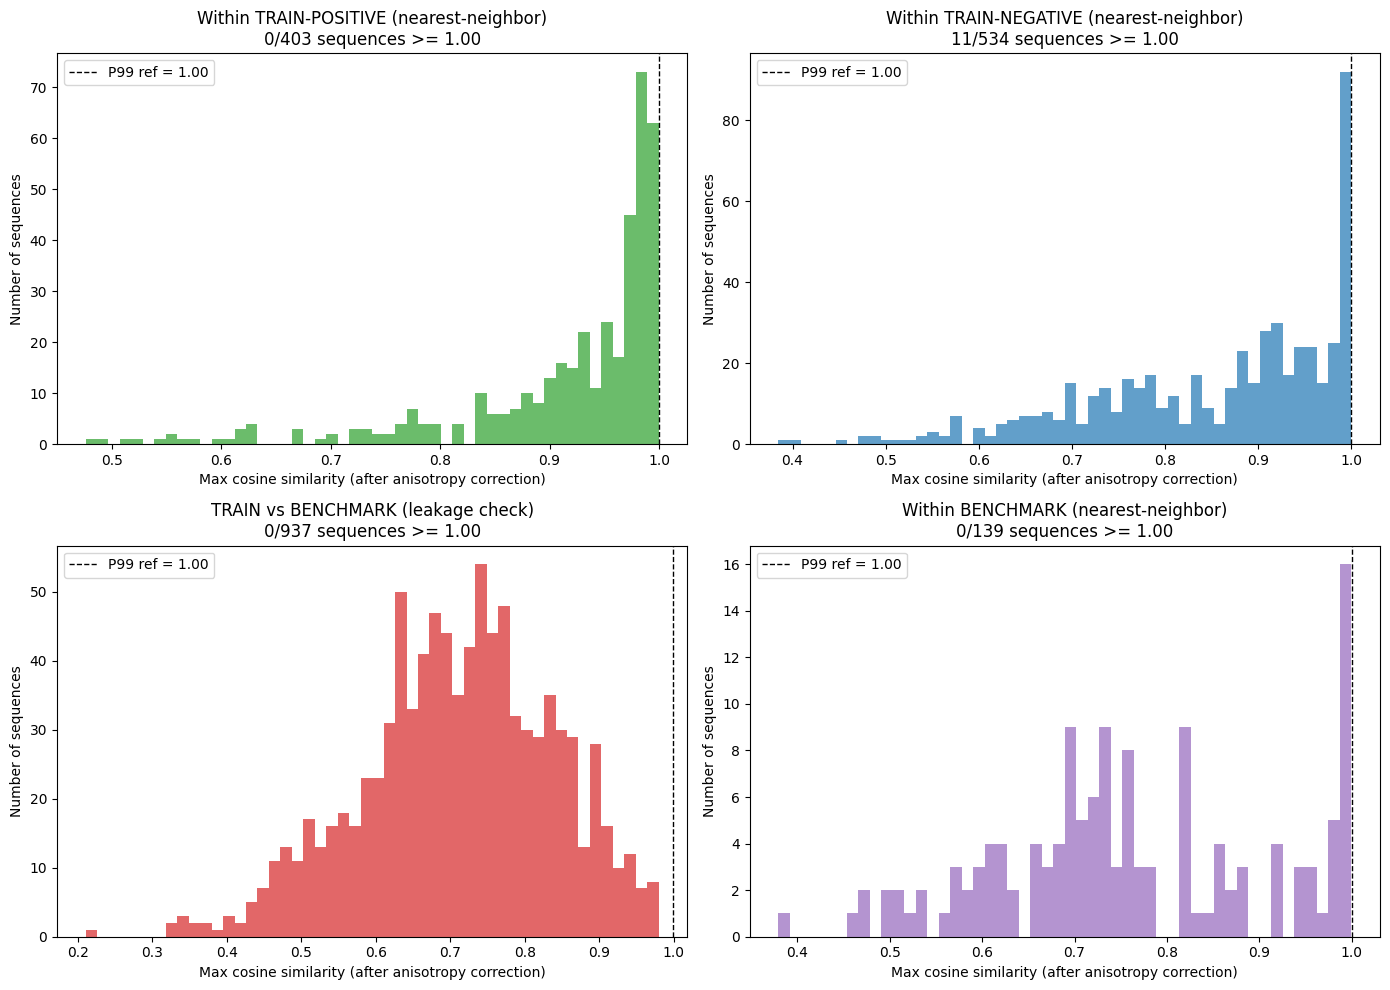


Interpretation:
  - If the distribution is still concentrated to the right (near 1.0) after this correction,
    it means there's a deeper problem (e.g., dataset dominated by 1 family).
  - If the distribution is now more spread out/normal, it confirms the old bug
    was about the metric (anisotropy), not actual duplication.
  - Points with similarity far in the right tail (>>P99) are still worth checking manually,
    but don't use raw 0.95 as an absolute reference anymore.


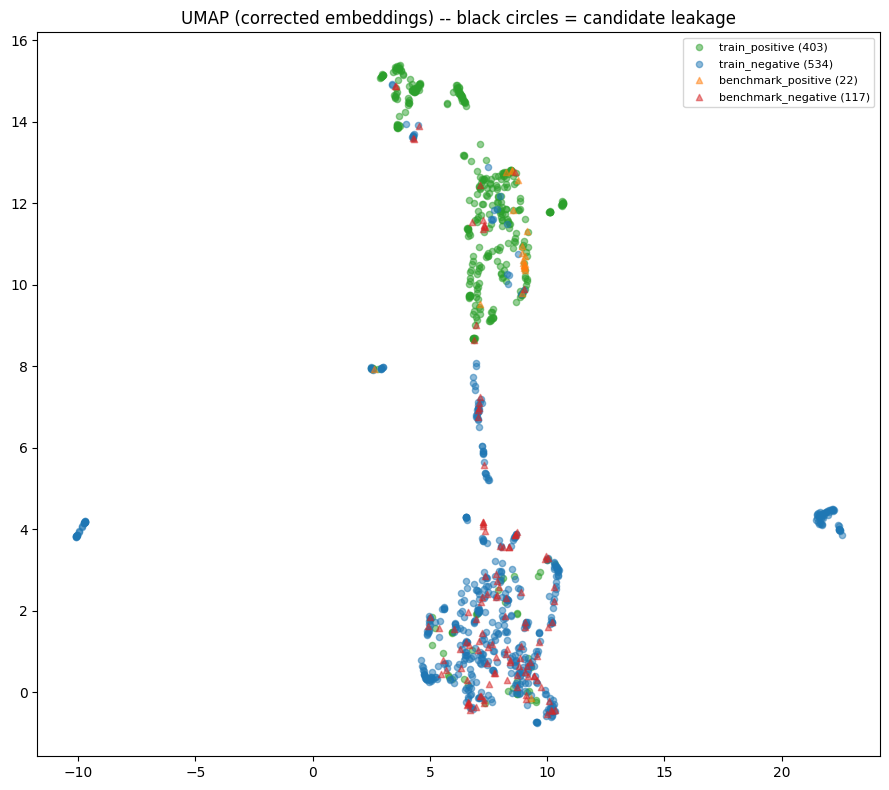

In [14]:
#@title # 8c. Duplication Visualization (anisotropy correction before cosine similarity)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

CURATION_DIR = DATASETS_DIR

df_all["dataset_group"] = np.where(df_all["label"] == 1, "train_positive", "train_negative")
df_bench["dataset_group"] = np.where(df_bench["label"] == 1, "benchmark_positive", "benchmark_negative")

df_combined = pd.concat([df_all, df_bench], ignore_index=True)
X_raw = np.vstack([X_all, X_bench_all])

# -----------------------------------------------------------------------------
# ANISOTROPY CORRECTION -- main fix.
# Mean-pooled embeddings from contextual models (ESM-2 etc.) tend to cluster in
# the SAME dominant direction for all sequences ("anisotropy"), making cosine
# similarity between ANY sequences high regardless of their true biological similarity.
# Subtract the global mean vector to remove this component
# (standard fix, known as "all-but-the-top").
# -----------------------------------------------------------------------------
mean_vec = X_raw.mean(axis=0, keepdims=True)
X_combined = X_raw - mean_vec

print(f"Total combined: {len(df_combined)} (train: {len(df_all)}, benchmark: {len(df_bench)})")
print("Embeddings have been corrected (mean-centered) before calculating similarity.")


def max_sim_excluding_self(X_query, X_reference, self_indices=None):
    sims = cosine_similarity(X_query, X_reference)
    if self_indices is not None:
        for i, idx in enumerate(self_indices):
            if idx is not None:
                sims[i, idx] = -1
    return sims.max(axis=1)


idx_train_pos = df_combined[df_combined["dataset_group"] == "train_positive"].index.to_numpy()
idx_train_neg = df_combined[df_combined["dataset_group"] == "train_negative"].index.to_numpy()
idx_bench = df_combined[df_combined["dataset_group"].str.startswith("benchmark")].index.to_numpy()
idx_train_all = np.concatenate([idx_train_pos, idx_train_neg])

row_pos_in_pos = np.arange(len(idx_train_pos))
sim_pos_vs_pos = max_sim_excluding_self(X_combined[idx_train_pos], X_combined[idx_train_pos], row_pos_in_pos)

row_neg_in_neg = np.arange(len(idx_train_neg))
sim_neg_vs_neg = max_sim_excluding_self(X_combined[idx_train_neg], X_combined[idx_train_neg], row_neg_in_neg)

sim_train_vs_bench = cosine_similarity(X_combined[idx_train_all], X_combined[idx_bench]).max(axis=1)

row_bench_in_bench = np.arange(len(idx_bench))
sim_bench_vs_bench = max_sim_excluding_self(X_combined[idx_bench], X_combined[idx_bench], row_bench_in_bench)

# -----------------------------------------------------------------------------
# The threshold is now determined from the DISTRIBUTION (percentile), not a
# fixed number 0.95 -- because the similarity scale changes entirely after correction.
# We use the 99th percentile of all combined panels as a visual reference for the "right tail".
# -----------------------------------------------------------------------------
all_sims_for_ref = np.concatenate([sim_pos_vs_pos, sim_neg_vs_neg, sim_bench_vs_bench])
flag_threshold = np.percentile(all_sims_for_ref, 99)
print(f"\nVisual threshold (99th percentile of within-set similarity): {flag_threshold:.3f}")
print("(No longer fixed 0.95 -- as similarity scale changes after anisotropy correction)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_specs = [
    (sim_pos_vs_pos, "Within TRAIN-POSITIVE (nearest-neighbor)", axes[0, 0], "tab:green"),
    (sim_neg_vs_neg, "Within TRAIN-NEGATIVE (nearest-neighbor)", axes[0, 1], "tab:blue"),
    (sim_train_vs_bench, "TRAIN vs BENCHMARK (leakage check)", axes[1, 0], "tab:red"),
    (sim_bench_vs_bench, "Within BENCHMARK (nearest-neighbor)", axes[1, 1], "tab:purple"),
]
for sims, title, ax, color in plot_specs:
    ax.hist(sims, bins=50, color=color, alpha=0.7)
    ax.axvline(flag_threshold, color="black", linestyle="--", linewidth=1, label=f"P99 ref = {flag_threshold:.2f}")
    n_suspect = (sims >= flag_threshold).sum()
    ax.set_title(f"{title}\n{n_suspect}/{len(sims)} sequences >= {flag_threshold:.2f}")
    ax.set_xlabel("Max cosine similarity (after anisotropy correction)")
    ax.set_ylabel("Number of sequences")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CURATION_DIR, "duplicate_check_histograms_corrected.png"), dpi=150)
plt.show()

print("\nInterpretation:")
print("  - If the distribution is still concentrated to the right (near 1.0) after this correction,")
print("    it means there's a deeper problem (e.g., dataset dominated by 1 family).")
print("  - If the distribution is now more spread out/normal, it confirms the old bug")
print("    was about the metric (anisotropy), not actual duplication.")
print("  - Points with similarity far in the right tail (>>P99) are still worth checking manually,")
print("    but don't use raw 0.95 as an absolute reference anymore.")

# -----------------------------------------------------------------------------
# PCA/UMAP still use the CORRECTED embeddings
# -----------------------------------------------------------------------------
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    coords = reducer.fit_transform(X_combined)
    method_name = "UMAP"
except Exception as e:
    print(f"[WARN] UMAP failed ({e}), falling back to PCA")
    coords = PCA(n_components=2, random_state=42).fit_transform(X_combined)
    method_name = "PCA"

df_combined["_x"], df_combined["_y"] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 8))
group_colors = {
    "train_positive": "tab:green", "train_negative": "tab:blue",
    "benchmark_positive": "tab:orange", "benchmark_negative": "tab:red",
}
group_markers = {
    "train_positive": "o", "train_negative": "o",
    "benchmark_positive": "^", "benchmark_negative": "^",
}
for g, color in group_colors.items():
    sub = df_combined[df_combined["dataset_group"] == g]
    ax.scatter(sub["_x"], sub["_y"], c=color, marker=group_markers[g], alpha=0.5, s=20, label=f"{g} ({len(sub)})")

train_leak_mask = sim_train_vs_bench >= flag_threshold
leak_points = df_combined.loc[idx_train_all[train_leak_mask]]
if len(leak_points) > 0:
    ax.scatter(leak_points["_x"], leak_points["_y"], facecolors="none", edgecolors="black",
               s=100, linewidths=1.5, label=f"Train similar to benchmark (>=P99): {len(leak_points)}")

ax.set_title(f"{method_name} (corrected embeddings) -- black circles = candidate leakage")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(os.path.join(CURATION_DIR, "duplicate_check_pca_umap_corrected.png"), dpi=150)
plt.show()

In [15]:
#@title # 9. Assemble final dataset

print("\n" + "=" * 60)
print("ASSEMBLY FINAL DATASET")
print("=" * 60)

# Remove helper columns (from visualization cell) before export -- not part of the data
helper_cols = ["dataset_group", "_x", "_y"]
df_final = df_all.drop(columns=[c for c in helper_cols if c in df_all.columns]).copy()

final_tier1 = df_final[df_final['tier'] == 1]
df_final = pd.concat([final_tier1], ignore_index=True)
df_final = df_final.drop_duplicates(subset="sequence", keep="first").reset_index(drop=True)

print(f"Final dataset: {len(df_final)} sequences")
print(f"  Positive: {len(df_final[df_final['label']==1])}")
print(f"  Negative: {len(df_final[df_final['label']==0])}")
print(f"  Ratio: 1:{len(df_final[df_final['label']==0]) / len(df_final[df_final['label']==1]):.1f}")

print("\nPer source:")
print(df_final.groupby(["source", "label"]).size())

# Save final results -- used in the training notebook
TRAIN_FINAL_FASTA = os.path.join(DATASETS_DIR, "train_final.fasta")
TRAIN_FINAL_CSV = os.path.join(DATASETS_DIR, "train_final_labels.csv")

with open(TRAIN_FINAL_FASTA, "w") as f:
    for _, r in df_final.iterrows():
        f.write(f">{r['id']}\n{r['sequence']}\n")
df_final.to_csv(TRAIN_FINAL_CSV, index=False)

print(f"\nSaved:")
print(f"  {TRAIN_FINAL_FASTA}")
print(f"  {TRAIN_FINAL_CSV}")
print(f"  {os.path.join(DATASETS_DIR, 'benchmark_final.fasta')}  (from cell 5d)")
print(f"  {os.path.join(DATASETS_DIR, 'benchmark_final_labels.csv')}  (from cell 5d)")
print("\nUse train_final.* and benchmark_final.* in the training notebook --")
print("NOT raw files -- so that all dedup/leakage fixes above are applied.")


ASSEMBLY FINAL DATASET
Final dataset: 937 sequences
  Positive: 403
  Negative: 534
  Ratio: 1:1.3

Per source:
source            label
PAZy              0         89
                  1        239
PED               0         34
                  1         32
PlasticDB         0        110
                  1        131
PlasticEnz_train  0        301
                  1          1
dtype: int64

Saved:
  /content/drive/MyDrive/InterPET/datasets/train_final.fasta
  /content/drive/MyDrive/InterPET/datasets/train_final_labels.csv
  /content/drive/MyDrive/InterPET/datasets/benchmark_final.fasta  (from cell 5d)
  /content/drive/MyDrive/InterPET/datasets/benchmark_final_labels.csv  (from cell 5d)

Use train_final.* and benchmark_final.* in the training notebook --
NOT raw files -- so that all dedup/leakage fixes above are applied.
